In [2]:
import numpy as np 
import pandas as pd

ratings = pd.read_csv("../data/ml-1m/ratings.dat",
                      sep="::",
                      engine="python",
                      names=["user_id", "movie_id", "rating", "timestamp"])

ratings = ratings.drop("timestamp", axis=1)
R = ratings.pivot(index="user_id", columns="movie_id", values="rating").fillna(0)
print(R)
                      

movie_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                               ...   
1          5.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
5          0.0   0.0   0.0   0.0   0.0   2.0   0.0   0.0   0.0   0.0  ...   
...        ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
6036       0.0   0.0   0.0   2.0   0.0   3.0   0.0   0.0   0.0   0.0  ...   
6037       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
6038       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
6039       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
6040       3.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   

In [4]:
import numpy as np 

U, S, Vt = np.linalg.svd(R)
print("User x User matrix", U.shape)
print("Covariance matrix", S.shape)
print("Item x Item matrix", Vt.shape)

User x User matrix (6040, 6040)
Covariance matrix (3706,)
Item x Item matrix (3706, 3706)


In [5]:
num_zeros = np.sum(S < 1e-12)
print(num_zeros)

43


In [6]:
d = 50

info_retain = np.sum(S[:d] ** 2) / np.sum(S ** 2)
print("Amount of information retained: ", info_retain)

Amount of information retained:  0.4959379130788273


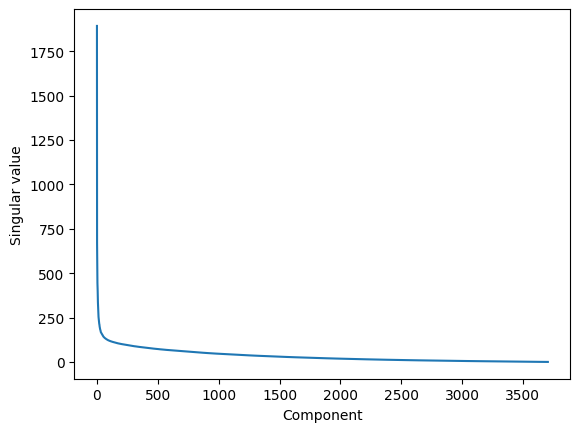

In [7]:
import matplotlib.pyplot as plt

plt.plot(S)
plt.xlabel("Component")
plt.ylabel("Singular value")
plt.show()

In [5]:
import pandas as pd 

df = pd.read_csv(
    "../data/ml-1m/ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings_per_user = df.groupby("user_id")["rating"].count()

print(ratings_per_user.loc[0:])

user_id
1        53
2       129
3        51
4        21
5       198
       ... 
6036    888
6037    202
6038     20
6039    123
6040    341
Name: rating, Length: 6040, dtype: int64


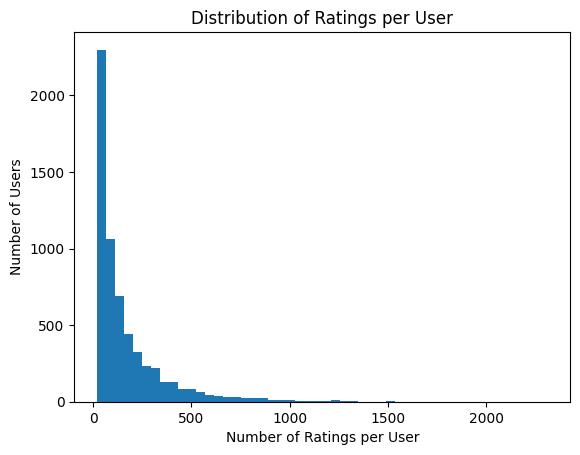

In [7]:
import matplotlib.pyplot as plt

ratings_per_user.plot(kind="hist", bins=50)

plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Ratings per User")

plt.show()